## **Pohon Keputusan**

### 1. DataSet

| No | Outlook  | Temperature | Humidity | Wind  | Play |
| -- | -------- | ----------- | -------- | ----- | ---- |
| 1  | Sunny    | Hot         | High     | False | No   |
| 2  | Sunny    | Hot         | High     | True  | No   |
| 3  | Overcast | Hot         | High     | False | Yes  |
| 4  | Rain     | Mild        | High     | False | Yes  |
| 5  | Rain     | Cool        | Normal   | False | Yes  |
| 6  | Rain     | Cool        | Normal   | True  | No   |
| 7  | Overcast | Cool        | Normal   | True  | Yes  |
| 8  | Sunny    | Mild        | High     | False | No   |
| 9  | Sunny    | Cool        | Normal   | False | Yes  |
| 10 | Rain     | Mild        | Normal   | False | Yes  |
| 11 | Sunny    | Mild        | Normal   | True  | Yes  |
| 12 | Overcast | Mild        | High     | True  | Yes  |
| 13 | Overcast | Hot         | Normal   | False | Yes  |
| 14 | Rain     | Mild        | High     | True  | No   |

### 2. Preprocessing Data

Tahap preprocessing data dilakukan untuk mempersiapkan dataset sebelum masuk ke proses pemodelan. Pada tahap ini, data dibersihkan, dipilih, dan diubah ke format yang sesuai agar dapat diproses dengan baik oleh algoritma machine learning.

Berikut adalah tahapan preprocessing yang dilakukan:

#### **a. CSV Reader**

Node CSV Reader digunakan untuk membaca dataset diabetes yang berbentuk file .csv. Data yang berhasil dibaca akan ditampilkan dalam bentuk tabel yang berisi seluruh fitur dan target class.

#### **b. Table Partitioner**

Node Table Partitioner digunakan untuk membagi dataset menjadi dua bagian:

* Data Training $\rightarrow$ digunakan untuk melatih model
* Data Testing $\rightarrow$ digunakan untuk menguji performa model

Pembagian ini penting agar model dapat dievaluasi secara objektif.

Datanya yaitu Proses Partisi Data (90:10)

* 90% Data Training ($\pm$13 baris): Digunakan untuk melatih model agar memahami pola data.
* 10% Data Testing ($\pm$1 baris): Digunakan untuk menguji keakuratan model dalam memprediksi data baru.

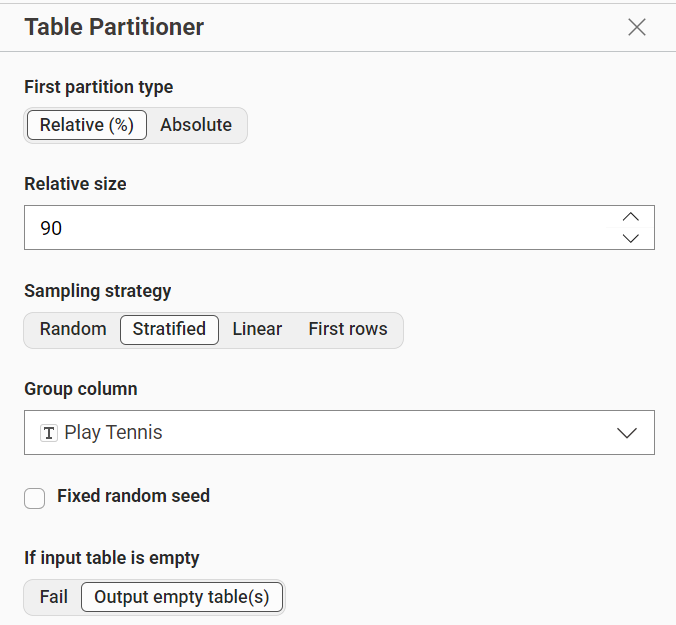

#### **c. Color Manager**

memberikan identitas visual berupa warna otomatis pada kolom "Play Tennis" untuk memudahkan pemisahan antara kategori secara cepat tanpa harus membaca teks satu per satu.

#### **d. Color Appender**

berfungsi untuk menyalin atau "menempelkan" skema warna yang sudah dibuat di Color Manager ke dalam tabel data yang berbeda (dalam hal ini, Data Testing).Proses ini memastikan data pengujian memiliki label warna yang sama dengan data pelatihan, sehingga hasil prediksi "Yes" atau "No" bisa langsung dibandingkan secara visual.Meskipun berstatus deprecated (versi lama), node ini sangat berguna untuk menjaga konsistensi tampilan warna di seluruh tahapan analisis data Anda.

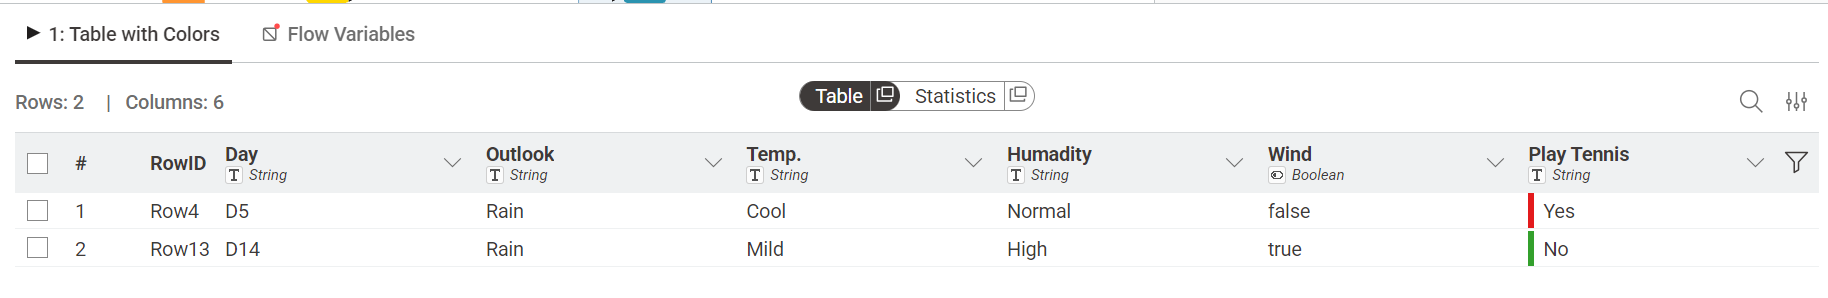



#### **e. Decision Tree Learner**

Bertindak sebagai "otak" yang mempelajari pola dari 14 baris data tersebut untuk menciptakan aturan prediksi otomatis pada kolom Play Tennis menggunakan metode statistik Gain Ratio.


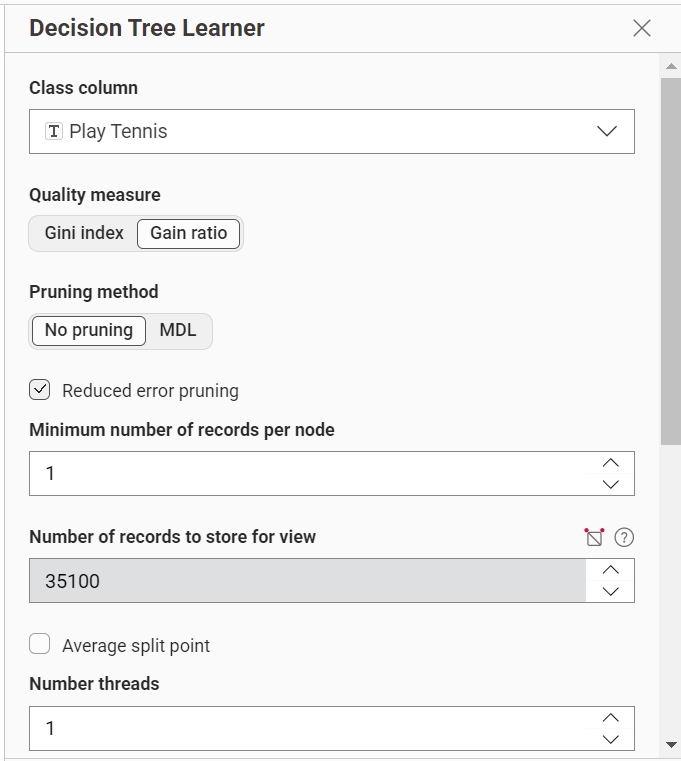


**Hasil Tree**


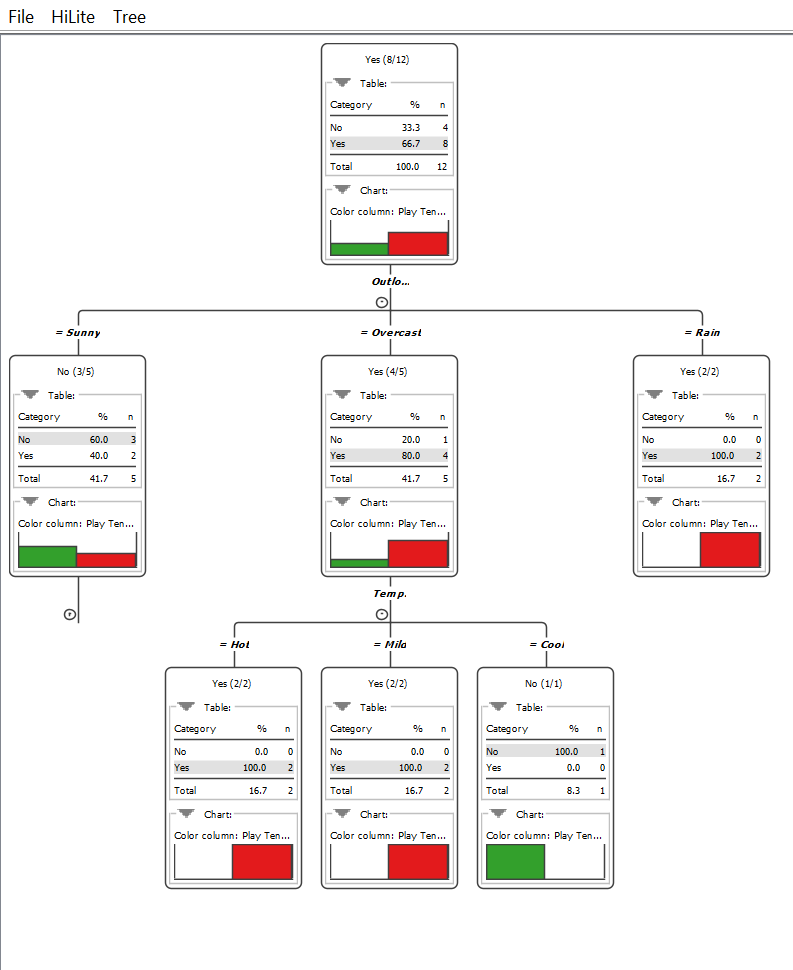


**PENJELASAN**

* **Root Node (Akar Paling Atas): Outlook**

  Pohon keputusan Anda menentukan bahwa Outlook (Cuaca) adalah faktor paling penting untuk ditanyakan pertama kali.

  * Dari total 12 data training, 8 orang berkata "Yes" dan 4 orang "No".

* **Percabangan Berdasarkan Outlook**

  Data kemudian dipecah menjadi tiga kondisi cuaca:

  * **Sunny (Cerah)**: Jika cuaca cerah, mayoritas (60%) justru berkata No (3 orang No, 2 orang Yes).

  * **Overcast (Mendung)**: Jika mendung, peluang bermain sangat tinggi (Yes 80%).

  * **Rain (Hujan**): Jika hujan, pada cabang ini 100% (2 data) menunjukkan hasil Yes.

* **Level Kedua: Temp. (Suhu)**

  Pada bagian tengah (saat cuaca Overcast), pohon membuat keputusan lebih dalam berdasarkan Temp. (Suhu):

  * Jika Hot atau Mild: Keputusannya adalah Yes (100% yakin).
  
  * Jika Cool: Keputusannya adalah No (100% yakin dari 1 data yang tersedia).



#### **e. Decision Tree Predictor**

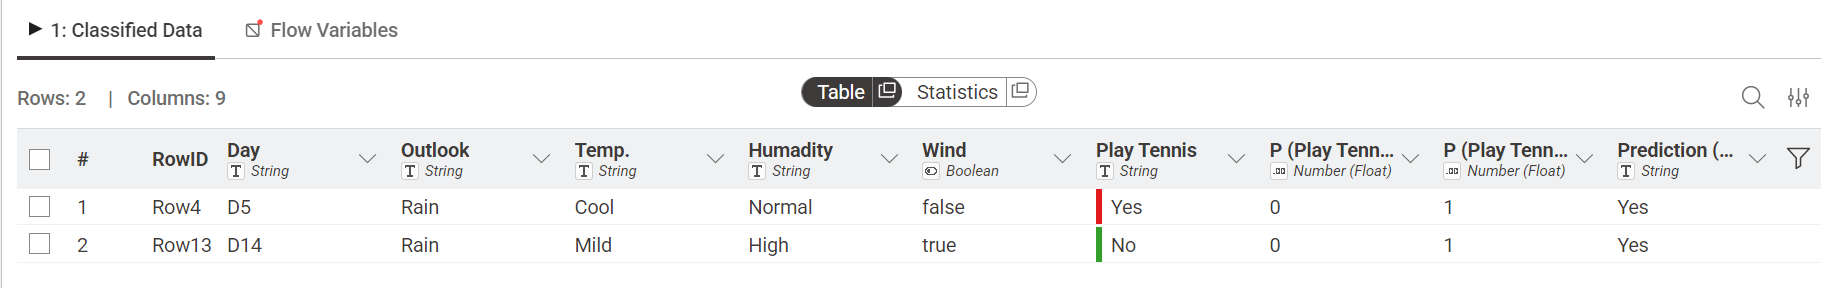


Berikut adalah penjelasan kolom-kolom pentingnya:

* Play Tennis: Ini adalah jawaban asli (faktual) yang ada di data Anda.

* Prediction (Play Tennis): Ini adalah hasil tebakan atau prediksi dari model Decision Tree yang sudah dibuat.

* P (Play Tennis=No/Yes): Ini menunjukkan tingkat kepercayaan model. Angka 1 pada kolom "Yes" berarti model 100% yakin bahwa jawabannya adalah "Yes".

* Analisis Hasil Data Anda:

  * Baris 1 (Row4): Model memprediksi "Yes" dan jawaban aslinya memang "Yes". Artinya, prediksi model Tepat.

  * Baris 2 (Row13): Model memprediksi "Yes", tetapi jawaban aslinya adalah "No". Artinya, pada baris ini prediksi model Meleset (Salah).

#### **f. Scorer (deprecated)**

Scorer berfungsi untuk mengevaluasi keakuratan model dengan cara membandingkan kolom jawaban asli (Play Tennis) dengan kolom hasil tebakan (Prediction Play Tennis).

**Hasil Counfusion Matrix**

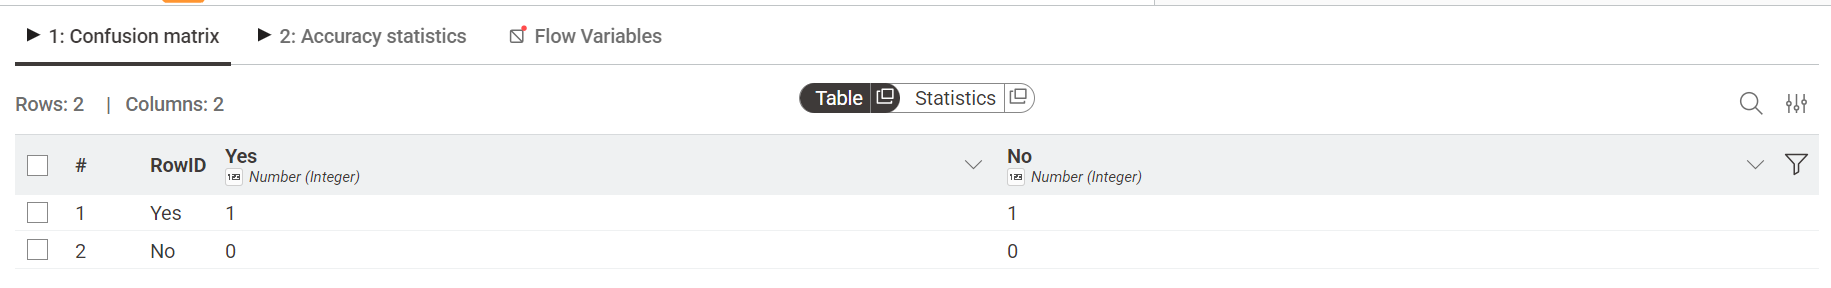

**PENJELASAN**

Confusion matrix ini menunjukkan bahwa dari 2 data, model memprediksi 1 data "Yes" dengan benar (True Positive), 1 data "Yes" salah jadi "No" (False Negative), tidak ada prediksi untuk data "No", sehingga akurasi model adalah 50% dan performanya masih kurang baik.

**Hasil Accuracy Statistic**

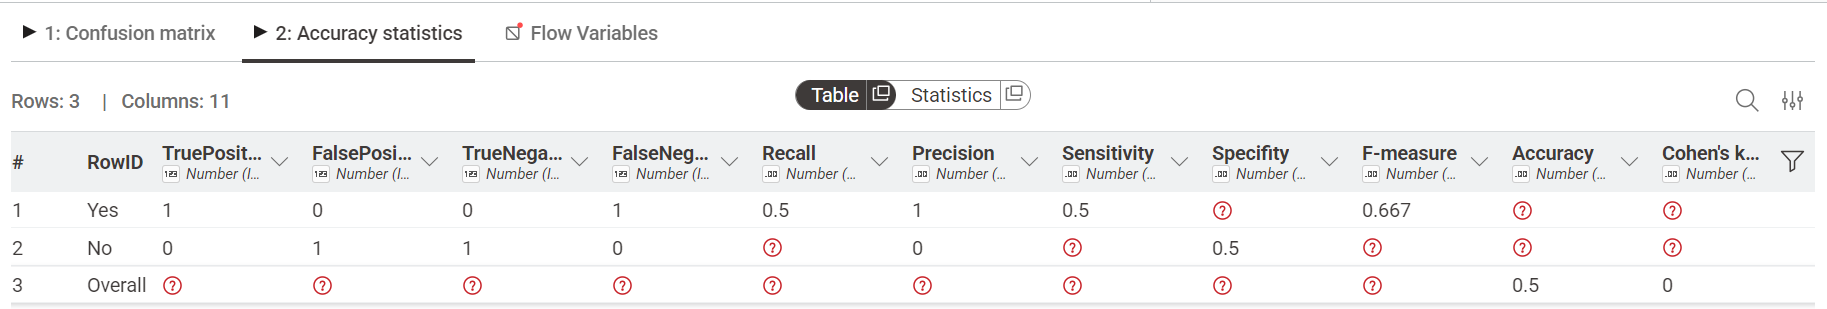

**PENJELASAN**

Tabel Accuracy Statistics menunjukkan bahwa model Anda memiliki akurasi keseluruhan sebesar 50%, di mana meskipun sangat tepat saat menebak "Yes" (Precision 1.0), model tersebut masih gagal mengenali pola secara sempurna karena hanya berhasil menebak 1 dari 2 data pengujian dengan benar.


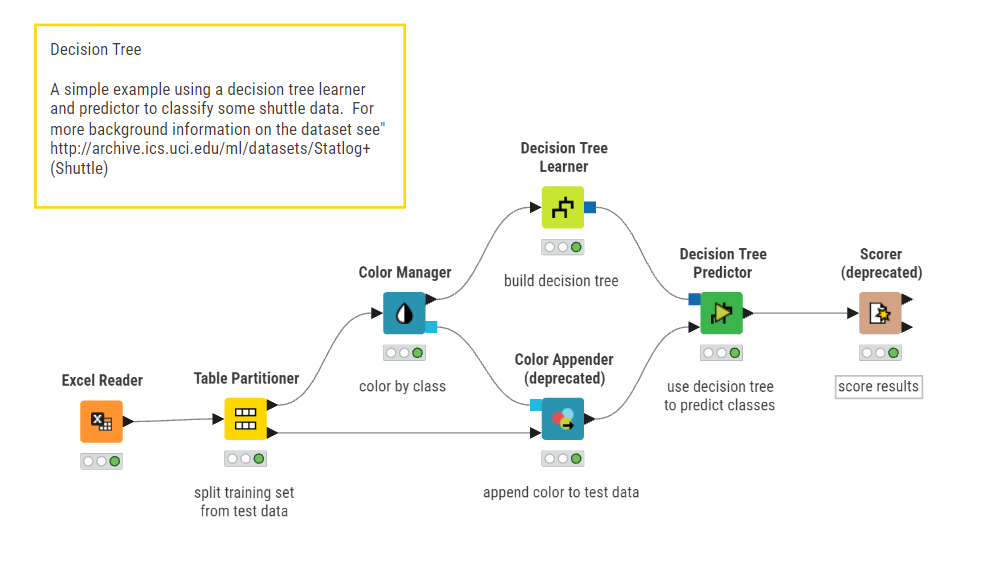